In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam


In [3]:

BASE_PATH = "/kaggle/input/datasets/jangedoo/utkface-new"

DATASET_PATH = None

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith(".jpg"):
            DATASET_PATH = root
            break
    if DATASET_PATH:
        break

print("Correct Dataset Path:", DATASET_PATH)
print("Total files:", len(os.listdir(DATASET_PATH)))


Correct Dataset Path: /kaggle/input/datasets/jangedoo/utkface-new/UTKFace
Total files: 23708


In [4]:
IMG_SIZE = 96

images = []
ages = []
nationalities = []

valid = 0

for file in os.listdir(DATASET_PATH):

    if not file.lower().endswith((".jpg", ".png")):
        continue

    try:
        parts = file.split("_")
        if len(parts) < 3:
            continue

        age = int(parts[0])
        race = int(parts[2])

        if race == 0:
            nationality = 0   # United States
        elif race == 1:
            nationality = 1   # African
        elif race in [2, 3]:
            nationality = 2   # Indian
        else:
            nationality = 3   # Other

        img_path = os.path.join(DATASET_PATH, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        images.append(img)
        ages.append(age)
        nationalities.append(nationality)

        valid += 1

    except:
        continue

images = np.array(images)
ages = np.array(ages)
nationalities = np.array(nationalities)

print("Valid Images Loaded:", valid)
print("Images shape:", images.shape)


Valid Images Loaded: 23705
Images shape: (23705, 96, 96, 3)


In [5]:
X_train, X_test, y_nat_train, y_nat_test, y_age_train, y_age_test = train_test_split(
    images, nationalities, ages, test_size=0.2, random_state=42
)

y_nat_train = to_categorical(y_nat_train, 4)
y_nat_test = to_categorical(y_nat_test, 4)


In [6]:
def build_nationality_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

nationality_model = build_nationality_model()
nationality_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771059536.750257      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
import gc
gc.collect()

history_nat = nationality_model.fit(
    X_train,
    y_nat_train,
    validation_data=(X_test, y_nat_test),
    epochs=5,
    batch_size=16
)


Epoch 1/5


I0000 00:00:1771059551.401662     129 service.cc:152] XLA service 0x7c77f8004420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771059551.401708     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771059551.842165     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  29/1186 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3679 - loss: 1.3512

I0000 00:00:1771059555.015795     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1186/1186 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4925 - loss: 1.1389 - val_accuracy: 0.6720 - val_loss: 0.8612
Epoch 2/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6890 - loss: 0.8219 - val_accuracy: 0.7359 - val_loss: 0.7116
Epoch 3/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7331 - loss: 0.7190 - val_accuracy: 0.7678 - val_loss: 0.6409
Epoch 4/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7630 - loss: 0.6497 - val_accuracy: 0.7747 - val_loss: 0.6317
Epoch 5/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7745 - loss: 0.6103 - val_accuracy: 0.7730 - val_loss: 0.6158


In [8]:
def build_age_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

age_model = build_age_model()
age_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,577 (15.20 MB)

 Trainable params: 3,984,577 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_age = age_model.fit(
    X_train,
    y_age_train,
    validation_data=(X_test, y_age_test),
    epochs=5,
    batch_size=16
)


Epoch 1/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 356.8030 - mae: 14.2809 - val_loss: 142.8139 - val_mae: 8.8734
Epoch 2/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 141.9059 - mae: 8.8613 - val_loss: 116.4491 - val_mae: 8.0214
Epoch 3/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 112.2345 - mae: 7.8521 - val_loss: 116.1533 - val_mae: 8.1707
Epoch 4/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 92.1651 - mae: 7.1419 - val_loss: 101.2834 - val_mae: 7.1979
Epoch 5/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 76.5646 - mae: 6.5197 - val_loss: 87.9106 - val_mae: 6.8544


In [10]:
nationality_model.save("nationality_model.keras")
age_model.save("age_model.keras")

print("Models saved successfully!")


Models saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step


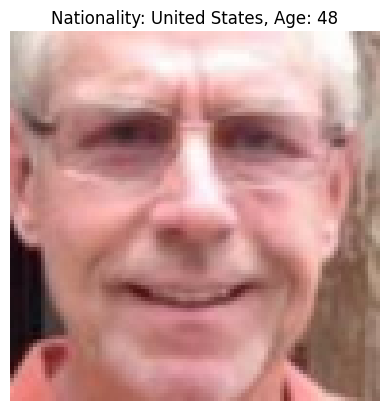

In [11]:
idx = np.random.randint(0, len(X_test))
sample = X_test[idx:idx+1]
nat_pred = np.argmax(nationality_model.predict(sample))
age_pred = int(age_model.predict(sample)[0][0])

labels = ["United States", "African", "Indian", "Other"]

plt.imshow(X_test[idx])
plt.title(f"Nationality: {labels[nat_pred]}, Age: {age_pred}")
plt.axis("off")
plt.show()


In [12]:
FER_PATH = "/kaggle/input/datasets/nicolejyt/facialexpressionrecognition/fer2013.csv"

emotion_df = pd.read_csv(FER_PATH)
print(emotion_df.shape)
emotion_df.head()

(35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [13]:
emotion_pixels = emotion_df["pixels"].tolist()
emotion_labels = emotion_df["emotion"].values

X_emotion = []
for pixel in emotion_pixels:
    img = np.array(pixel.split(), dtype="float32")
    img = img.reshape(48, 48, 1)
    X_emotion.append(img)

X_emotion = np.array(X_emotion) / 255.0
y_emotion = to_categorical(emotion_labels, 7)

print("Emotion Images:", X_emotion.shape)
print("Emotion Labels:", y_emotion.shape)


Emotion Images: (35887, 48, 48, 1)
Emotion Labels: (35887, 7)


In [14]:

X_emo_train, X_emo_test, y_emo_train, y_emo_test = train_test_split(
    X_emotion, y_emotion, test_size=0.2, random_state=42
)


In [15]:
def build_emotion_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

emotion_model = build_emotion_model()
emotion_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_emotion = emotion_model.fit(
    X_emo_train,
    y_emo_train,
    validation_data=(X_emo_test, y_emo_test),
    epochs=10,
    batch_size=64
)


Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2489 - loss: 1.8253 - val_accuracy: 0.3803 - val_loss: 1.5782
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3889 - loss: 1.5709 - val_accuracy: 0.4351 - val_loss: 1.4561
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4512 - loss: 1.4372 - val_accuracy: 0.4840 - val_loss: 1.3537
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4795 - loss: 1.3628 - val_accuracy: 0.5093 - val_loss: 1.2885
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4998 - loss: 1.3081 - val_accuracy: 0.5235 - val_loss: 1.2515
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5337 - loss: 1.2419 - val_accuracy: 0.5309 - val_loss: 1.2408
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5382 - loss: 1.2117 - val_accuracy: 0.5408 - val_loss: 1.2100
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5493 - loss: 1.1780 - val_accuracy: 

In [17]:
emotion_model.save("emotion_model.keras")
print("Emotion model saved successfully!")


Emotion model saved successfully!


In [18]:
from sklearn.cluster import KMeans

def detect_dress_color_advanced(image):
    
    img = (image * 255).astype("uint8")
    
    h, w, _ = img.shape
    
    lower_part = img[int(h*0.55):h, 0:w]
    
    lower_part = cv2.resize(lower_part, (100,100))
    
    hsv = cv2.cvtColor(lower_part, cv2.COLOR_RGB2HSV)
    
    pixels = hsv.reshape((-1,3))
    
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(pixels)
    
    counts = np.bincount(kmeans.labels_)
    dominant = kmeans.cluster_centers_[np.argmax(counts)]
    
    h_val, s_val, v_val = dominant
    
    # Color Mapping (HSV Based)
    # Black
    if v_val < 50:
        return "Black"

    # White
    elif s_val < 40 and v_val > 180:
        return "White"

    # 🔥 PINK (low saturation red, high brightness)
    elif (0 <= h_val < 10 or 160 <= h_val <= 180) and s_val < 120 and v_val > 150:
        return "Pink"

    # Red (high saturation red)
    elif (0 <= h_val < 10 or 160 <= h_val <= 180):
        return "Red"

    # Orange
    elif 10 <= h_val < 25:
        return "Orange"

    # Yellow
    elif 25 <= h_val < 35:
        return "Yellow"

    # Green
    elif 35 <= h_val < 85:
        return "Green"

    # Blue
    elif 85 <= h_val < 125:
        return "Blue"

    # Purple
    elif 125 <= h_val < 160:
        return "Purple"

    else:
        return "Other"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Nationality: United States
Emotion: Fear
Age: 32


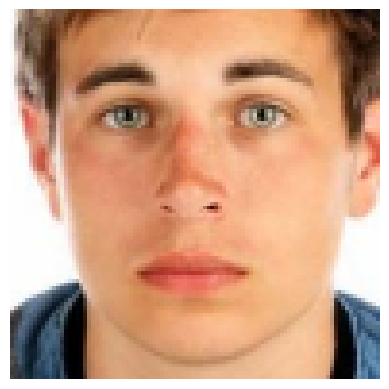

In [20]:
nationality_labels = ["United States", "African", "Indian", "Other"]
emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

idx = np.random.randint(0, len(X_test))
face = X_test[idx:idx+1]

nat_pred = np.argmax(nationality_model.predict(face))
predicted_nationality = nationality_labels[nat_pred]

age_pred = int(age_model.predict(face)[0][0])

emo_img = cv2.cvtColor((face[0]*255).astype("uint8"), cv2.COLOR_RGB2GRAY)
emo_img = cv2.resize(emo_img, (48,48))
emo_img = emo_img.reshape(1,48,48,1) / 255.0

emo_pred = np.argmax(emotion_model.predict(emo_img))
predicted_emotion = emotion_names[emo_pred]

dress_color = detect_dress_color_advanced(face[0])



print("Nationality:", predicted_nationality)

if predicted_nationality == "Indian":
    print("Emotion:", predicted_emotion)
    print("Age:", age_pred)
    print("Dress Color:", dress_color)

elif predicted_nationality == "United States":
    print("Emotion:", predicted_emotion)
    print("Age:", age_pred)

elif predicted_nationality == "African":
    print("Emotion:", predicted_emotion)
    print("Dress Color:", dress_color)

else:
    print("Emotion:", predicted_emotion)

# 🔹 Show Image
plt.imshow(face[0])
plt.axis("off")
plt.show()


In [21]:
# Save models
nationality_model.save("nationality_model.keras")
age_model.save("age_model.keras")
emotion_model.save("emotion_model.keras")

print("All models saved successfully!")

All models saved successfully!
